In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)


In [162]:
# Define the action
class ScalarAction(lhmc.Action):
    @staticmethod
    @jax.jit
    def _Sjax(phi, kappa, lamb):
        S = phi**2
        
        for ax in range(d):
            S -= 2 * kappa * phi * phi.nn_field(ax)

        S += lamb * (phi**2 - 1)**2    
        return S
    
    def _compute_forces(self):
        self.grads = {
            'phi': jax.jit(jax.grad(lambda phi, kappa, lamb: jnp.sum(self._Sjax(phi, kappa, lamb).field))),
        }

        def force_func(fields):
#            return {'phi': self.exact_force(fields['phi'], self.params['kappa'], self.params['lamb'])}
            return {'phi': self.grads['phi'](fields['phi'], self.params['kappa'], self.params['lamb']) }

        self.forces = force_func
    
    @staticmethod
    @jax.jit
    def exact_force(phi, kappa, lamb):
        J = phi.nn_field(axis=0, shift=1) + phi.nn_field(axis=0, shift=-1)
        for ax in range(1,d):
            J += phi.nn_field(axis=ax, shift=1)
            J += phi.nn_field(axis=ax, shift=-1)

        F = -2 * kappa * J
        F += 2 * phi.field
        F += 4 * lamb * (phi.field**2 - 1) * phi.field

        return F
            
    
    def _S(self):
        return self._Sjax(self.fields['phi'], self.params['kappa'], self.params['lamb'])



In [163]:
jnp.sum(S4._Sjax(phi4, 0.1, 0.1).field)

Array(51.2, dtype=float64)

In [164]:
print(phi4.field[0,0,0,0])

test_force_1 = S4.forces({'phi': phi4})['phi'].field
print(test_force_1[0,0,0,0])

test_force_2 = S4.exact_force(phi4, S4.params['kappa'], S4.params['lamb'])
print(test_force_2.field[0,0,0,0])

jnp.sum(test_force_2.field + (-1)*test_force_1)

1.0
-0.9070399999999998
-0.9070399999999998


Array(0., dtype=float64)

In [187]:
# First test case: exercise 2.5
d = 3
Lat4 = lat.SquareLattice(dims=((4,)*d))
phi4 = lat.LatticeField(Lat4)
phi4.field = np.ones_like(phi4.field)

S4 = ScalarAction({'phi': phi4}, params={'kappa': 0.18169, 'lamb': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC_leap = lhmc.HMCEvolver(
        action=S4,
        seed=72345,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    HMC_om = lhmc.HMCEvolver(
        action=S4,
        seed=87735,
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )
    for _ in range(50):
        HMC_leap.evolve(warmup=True)
        HMC_om.evolve(warmup=True)

    abs_dH_leap = np.abs(np.array(HMC_leap.monitor['delta_H']))
    abs_dH_om = np.abs(np.array(HMC_om.monitor['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))


Least Square Fit:
  chi2/dof [dof] = 0.28 [5]    Q = 0.93    logGBF = 7.7657

Parameters:
              a   -0.00126 (93)      [    0 (100) ]  
              b      18.0 (1.5)      [    0 (100) ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08*,1e-10,1e-10)    (itns/time = 3/0.0)
  fitter = scipy_least_squares    method = trf

Least Square Fit:
  chi2/dof [dof] = 0.3 [5]    Q = 0.91    logGBF = 14.644

Parameters:
              a   -0.000024 (91)       [    0 (100) ]  
              b        1.81 (13)       [    0 (100) ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08,1e-10*,1e-10)    (itns/time = 3/0.0)
  fitter = scipy_least_squares    method = trf



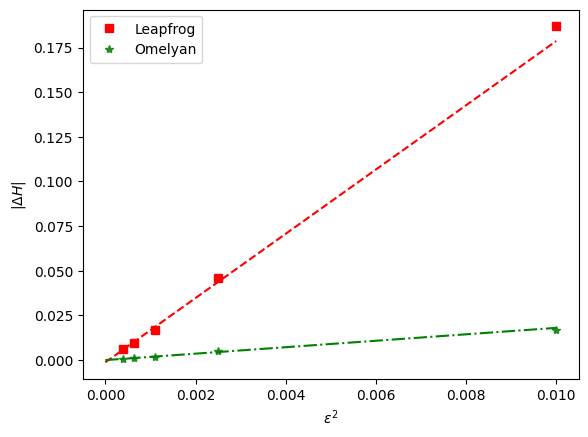

In [197]:
#Figure 2.2
plt.plot(all_eps**2, gv.mean(all_dH_leap), ls=' ', marker='s', color='red', label='Leapfrog')
plt.plot(all_eps**2, gv.mean(all_dH_om), ls=' ', marker='*', color='forestgreen', label='Omelyan')

def lin(x,p):
    return p['a'] + p['b']*x

fit_leap = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_leap), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,100)}, fcn=lin)
print(fit_leap)

eps_ls = np.linspace(0,0.1,100)
plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_leap.p)), ls='--', color='red')

fit_om = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_om), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,100)}, fcn=lin)
print(fit_om)

plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_om.p)), ls='-.', color='green')

plt.xlabel('$\epsilon^2$')
plt.ylabel('$|\Delta H|$')
plt.legend()

Another technical plot first: let's do figure 2.4.

In [178]:
# First test case: exercise 2.5
d = 3
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
#phi6.field = np.ones_like(phi6.field)

S6 = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

all_Nstep = np.array([4, 5, 7, 8, 10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_acc_rate = []

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC = lhmc.HMCEvolver(
        action=S6,
        seed=7245,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )

    for _ in range(1000):
        HMC.evolve(warmup=False)

    all_acc_rate.append(np.mean(np.array(HMC.monitor['accept'])))
    

Text(0, 0.5, 'acc rate')

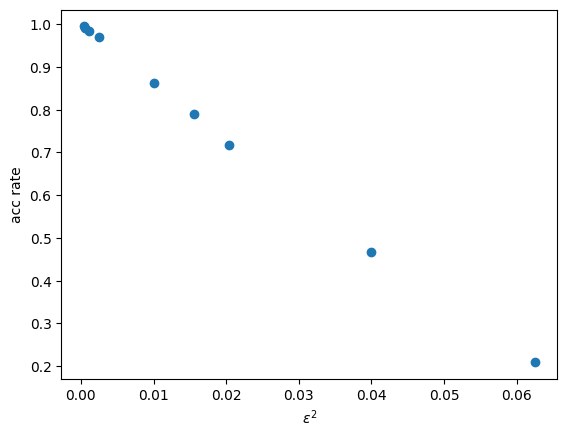

In [179]:
plt.plot(all_eps**2, all_acc_rate, ls=' ', marker='o')

plt.xlabel('$\epsilon^2$')
plt.ylabel('acc rate')

Text(0, 0.5, '$1/\\epsilon/$ acc rate [cost]')

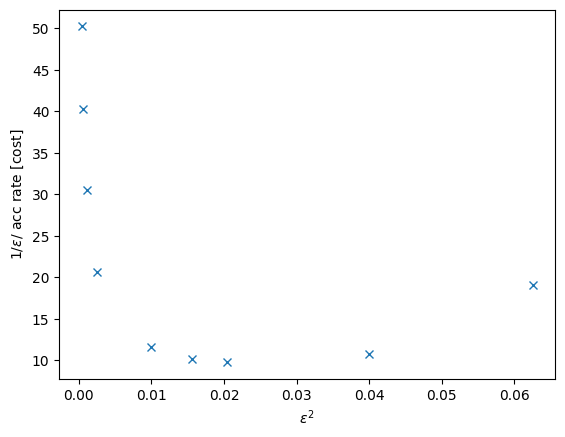

In [180]:
plt.plot(all_eps**2, 1/all_eps/all_acc_rate, ls=' ', marker='x')
plt.xlabel('$\epsilon^2$')
plt.ylabel('$1/\epsilon/$ acc rate [cost]')

Some additional technical tests.  Let's verify that $e^{-\Delta H}$ averages to 1 properly.

In [87]:
HMC = lhmc.HMCEvolver(
    action=ScalarAction({'phi': phi6}, params={'kappa': 0.18, 'lamb': 1.145}),
    #action=ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689}),
    seed=21245,
    integrator=lhmc.LeapfrogIntegrator(eps=0.1, Nstep=10),
)

for _ in range(10000):
    HMC.evolve()

1.008(25)

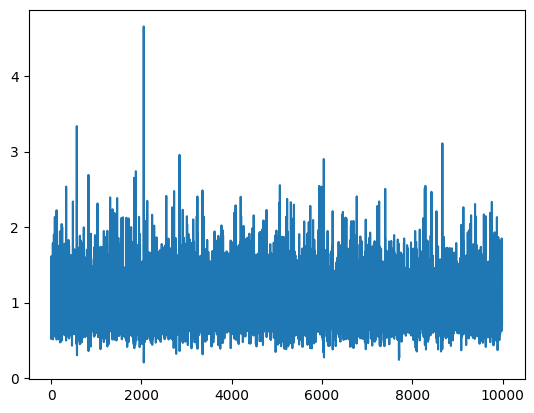

In [88]:
edH = np.exp(-np.array(HMC.monitor['delta_H']))
plt.plot(edH[10:])
gv.dataset.avg_data(edH[100::50])  # Block by 50, should be consistent with 1

Now on to figure 2.3 and comparing HMC to MD.

In [5]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.field)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [206]:
%%prun -s cumulative

# Second test case: figure 2.3
d = 3
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
phi6.field = np.ones_like(phi6.field)

#S6_HMC = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})
#S6_HMD = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

all_Nstep = np.array([4,5,6,7,8,10])
#all_Nstep = np.array([4])
# Try tau = 2
all_eps = 1/all_Nstep
m2_HMC = []
m2_HMD = []

raw_HMC = []
mon_HMC = []

for eps, Nstep in zip(all_eps, all_Nstep):
    print(eps, Nstep)

    # WARNING: instantiating both from the same action object causes
    # exchange of information between the two HMCEvolvers!
    # 
    # I should figure out a clean fix to this...
    #

    #S6_HMC.fields['phi'] = phi6.copy()
    #S6_HMD.fields['phi'] = phi6.copy()
    
    HMC = lhmc.HMCEvolver(
        #action=ScalarAction({'phi': phi6}, params={'kappa': 0.18, 'lamb': 1.145}),
        action=ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689}),
        seed=73645+Nstep,
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
        observables={'mag': (mag_obs, 100)},
    )
    
    HMD = lhmc.HMCEvolver(
        #action=ScalarAction({'phi': phi6}, params={'kappa': 0.18, 'lamb': 1.145}),
        action=ScalarAction({'phi': phi6.copy()}, params={'kappa': 0.185825, 'lamb': 1.1689}),
        seed=86735+Nstep,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
        observables={'mag': (mag_obs, 100)},
    )

#    for _ in range(200):
#        HMC.evolve(warmup=True)
#        HMD.evolve(warmup=True)

#    HMC.obs_chain = {'mag': []}
#    HMD.obs_chain = {'mag': []}
    
    for _ in range(100):
        HMC.evolve(ntraj=1000, warmup=False)
        HMD.evolve(ntraj=1000, warmup=True)

    raw_m2_HMC = (np.array(HMC.obs_chain['mag'])[:,1])/6**d
    raw_m2_HMD = (np.array(HMD.obs_chain['mag'])[:,1])/6**d

    raw_HMC.append(np.array(HMC.obs_chain['mag']))
    mon_HMC.append(HMC.monitor)
    
    m2_HMC.append(gv.dataset.avg_data(raw_m2_HMC))
    m2_HMD.append(gv.dataset.avg_data(raw_m2_HMD))



0.25 4
0.2 5
0.16666666666666666 6
0.14285714285714285 7
0.125 8
0.1 10
 

         46535598 function calls (46499474 primitive calls) in 66.502 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001   68.121   68.121 {built-in method builtins.exec}
        1    0.008    0.008   68.120   68.120 <string>:1(<module>)
     1200    3.972    0.003   68.030    0.057 hmc.py:438(evolve)
  1200000   20.650    0.000   42.919    0.000 hmc.py:402(MD_traj)
  3600597    1.515    0.000   21.139    0.000 lattice.py:114(_tree_unflatten)
  3600598   19.472    0.000   19.623    0.000 lattice.py:79(__init__)
  1200000    5.792    0.000    7.618    0.000 hmc.py:425(get_momentum)
913885/913165    1.330    0.000    7.394    0.000 profiler.py:311(wrapper)
   913097    0.273    0.000    5.338    0.000 array.py:258(__bool__)
   913097    1.259    0.000    3.738    0.000 array.py:555(_value)
   913259    3.326    0.000    3.524    0.000 array_methods.py:251(deferring_binary_op)
     1200    2.719    0

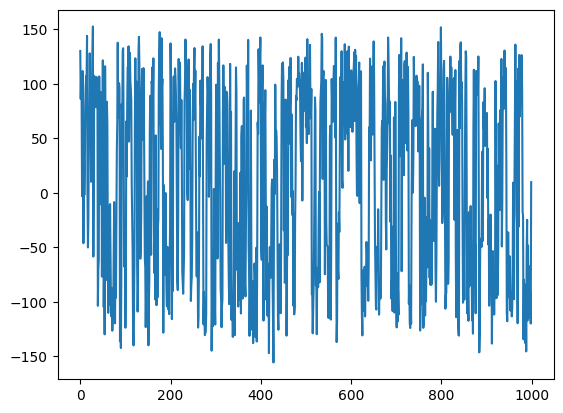

In [209]:
mtest = np.array(HMD.obs_chain['mag'])
plt.plot(mtest[:,0])

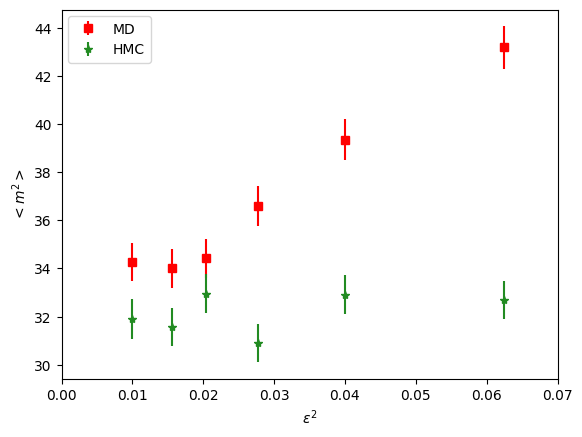

In [210]:
plt.errorbar(all_eps**2, gv.mean(m2_HMD), gv.sdev(m2_HMD), ls=' ', marker='s', color='red', label='MD')
plt.errorbar(all_eps**2, gv.mean(m2_HMC), gv.sdev(m2_HMC), ls=' ', marker='*', color='forestgreen', label='HMC')

plt.xlim(0,0.07)
plt.xlabel('$\epsilon^2$')
plt.ylabel('$<m^2>$')
plt.legend()

0.8996817322264778 0.9012
0.9451939020703025 0.9449
0.9616205592427588 0.9648
0.9726915578434707 0.9734
0.9789270924573786 0.9766
0.9865687010731422 0.9871


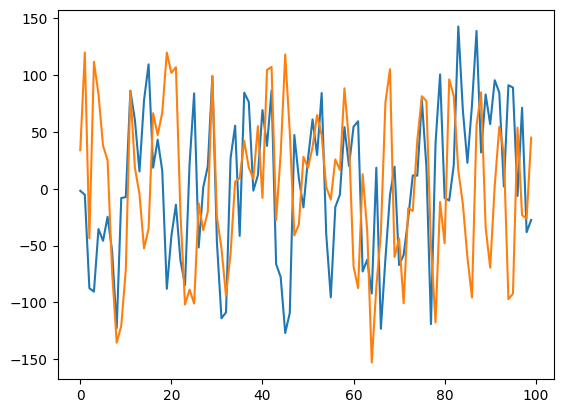

In [201]:
plt.plot(raw_HMC[0][:,0])
plt.plot(raw_HMC[1][:,0])

for i in range(len(mon_HMC)):
    print(np.mean(np.minimum(np.ones_like(mon_HMC[i]['P_acc']),np.array(mon_HMC[i]['P_acc']))), np.mean(mon_HMC[i]['accept']))

Finally the big physics result, figure 2.5!

In [36]:
from tqdm import tqdm

d = 3

all_kappa = np.array([0.05, 0.10, 0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22])
all_L = (6,8,10)

mag_k = {}

for L in tqdm(all_L):
    mag_k[L] = []

    Lat = lat.SquareLattice(dims=((L,)*d))
    phi = lat.LatticeField(Lat)

    for k in all_kappa:
        S6 = ScalarAction({'phi': phi}, params={'kappa': k, 'lamb': 1.1689})
    
        HMC = lhmc.HMCEvolver(
            action=S6,
            seed=72645,
            integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
            observables={'mag': (mag_obs, 50)},
        )
    
        HMC.evolve(ntraj=100, warmup=True)
    
        for _ in range(200):
            HMC.evolve(ntraj=100)
    
        raw_m = np.abs(np.array(HMC.obs_chain['mag'])[10:,0])/L**d
    
        mag_k[L].append(gv.dataset.avg_data(raw_m))
    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:15<00:00, 25.21s/it]


(0.15, 0.22)

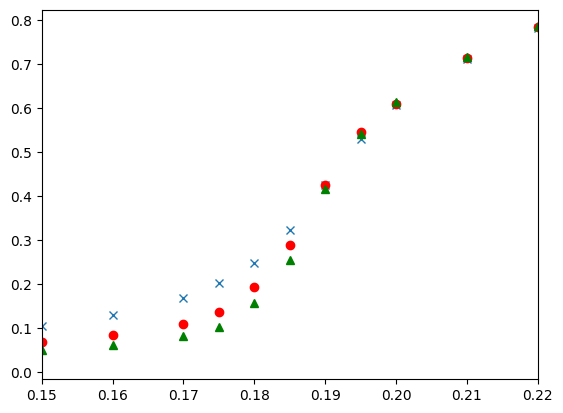

In [38]:
plt.plot(all_kappa, gv.mean(mag_k[6]), ls=' ', marker='x')
plt.plot(all_kappa, gv.mean(mag_k[8]), ls=' ', marker='o', color='red')
plt.plot(all_kappa, gv.mean(mag_k[10]), ls=' ', marker='^', color='green')

plt.xlim(0.15, 0.22)

Autocorrelation analysis...

In [80]:
d = 3
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)

HMC = lhmc.HMCEvolver(
    action=ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689}),
    #action=ScalarAction({'phi': phi6}, params={'kappa': 0.18, 'lamb': 1.145}),
    seed=21245,
    integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
    observables={'mag': (mag_obs, 1)},
)

HMC.evolve(ntraj=1000, warmup=True)

for _ in tqdm.tqdm(range(1000)):
    HMC.evolve(ntraj=1000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:01<00:00, 16.18it/s]


In [59]:
dH = np.array(HMC.monitor['delta_H'])
gv.dataset.avg_data(np.exp(-dH))

1.000001(33)

0.0113(39)

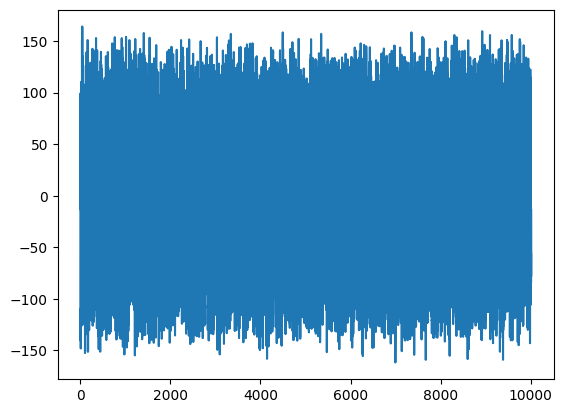

In [81]:
m = np.array(HMC.obs_chain['mag'])[:,0]
plt.plot(m[::100])

gv.dataset.avg_data(m[::100]/6**3)

In [82]:
mu, Ns = np.mean(m), len(m)
print(mu, Ns)

def Gamma(t):
    C1 = m - mu
    C2 = np.roll(m, t) - mu
    return gv.dataset.avg_data(C1[:Ns-t] * C2[:Ns-t] / (Ns - t))

2.646535105147736 1001000


<ErrorbarContainer object of 3 artists>

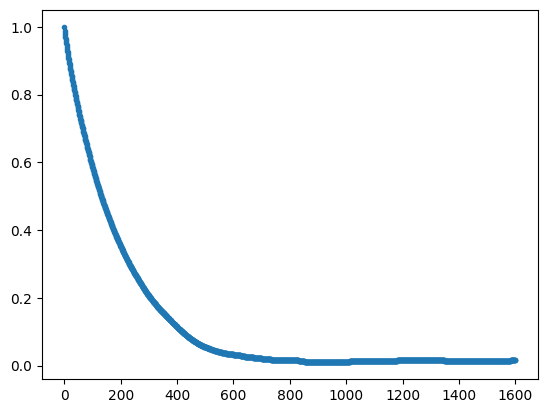

In [85]:
gam = [ Gamma(t)/Gamma(0) for t in range(0,1600) ]
plt.errorbar(range(0,1600), gv.mean(gam), gv.sdev(gam), ls=' ', marker='.')

<ErrorbarContainer object of 3 artists>

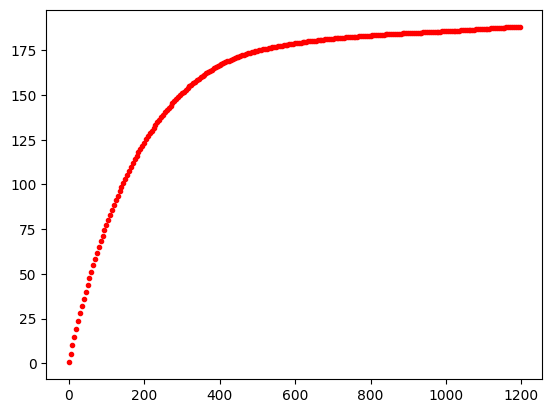

In [86]:
def tau(W):
    return 0.5 + np.sum(gam[:W])

taus = [ tau(W) for W in range(0,1200,5) ]
plt.errorbar(range(0,1200,5), gv.mean(taus), gv.sdev(taus), ls=' ', marker='.', color='red')